In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [12]:
df = pd.read_csv('dataset.csv', sep=";")
df

,id,antecedencia_da_reserva,mes_chegada,dia_chegada,noites_da_estadia,noites_fim_de_semana,hotel_de_praia,regime,adultos,criancas,bebes,ja_cliente,cancelamentos_anteriores,reservas_anteriores_nao_canceladas,alteracoes_da_reserva,total_de_pedidos,tipo_deposito,cancelada
0,1,26,November,25,7,2,yes,HB - Half Board,3,0,0,no,0,0,0,2,No Deposit,no
1,2,31,June,1,2,0,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,Non Refund,yes
2,5,4,March,17,3,0,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,No Deposit,yes
3,8,6,December,1,1,0,yes,BB - Bed & Breakfast,1,0,0,no,0,0,0,2,No Deposit,no
4,12,65,March,12,4,2,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,No Deposit,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,78545,108,June,11,2,0,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,1,No Deposit,no
19996,78547,209,May,23,2,0,no,HB - Half Board,2,0,0,no,0,0,0,0,No Deposit,no
19997,78554,3,October,17,4,2,no,BB - Bed & Breakfast,1,0,0,no,0,0,0,0,No Deposit,no
19998,78555,121,October,31,1,1,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,No Deposit,no


In [13]:
df = df.set_index("id")
df

,antecedencia_da_reserva,mes_chegada,dia_chegada,noites_da_estadia,noites_fim_de_semana,hotel_de_praia,regime,adultos,criancas,bebes,ja_cliente,cancelamentos_anteriores,reservas_anteriores_nao_canceladas,alteracoes_da_reserva,total_de_pedidos,tipo_deposito,cancelada
id,,,,,,,,,,,,,,,,,
1,26,November,25,7,2,yes,HB - Half Board,3,0,0,no,0,0,0,2,No Deposit,no
2,31,June,1,2,0,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,Non Refund,yes
5,4,March,17,3,0,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,No Deposit,yes
8,6,December,1,1,0,yes,BB - Bed & Breakfast,1,0,0,no,0,0,0,2,No Deposit,no
12,65,March,12,4,2,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,0,No Deposit,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78545,108,June,11,2,0,no,BB - Bed & Breakfast,2,0,0,no,0,0,0,1,No Deposit,no
78547,209,May,23,2,0,no,HB - Half Board,2,0,0,no,0,0,0,0,No Deposit,no
78554,3,October,17,4,2,no,BB - Bed & Breakfast,1,0,0,no,0,0,0,0,No Deposit,no


In [14]:
d_mes_chegada = pd.get_dummies(df['mes_chegada'])
d_hotel_de_praia = pd.get_dummies(df['hotel_de_praia'])
d_regime = pd.get_dummies(df['regime'])
d_ja_cliente = pd.get_dummies(df['ja_cliente'])
d_tipo_deposito = pd.get_dummies(df['tipo_deposito'])

In [15]:
df = pd.concat([df, d_mes_chegada], axis=1).reindex(df.index)
df = pd.concat([df, d_hotel_de_praia], axis=1).reindex(df.index)
df = pd.concat([df, d_regime], axis=1).reindex(df.index)
df = pd.concat([df, d_ja_cliente], axis=1).reindex(df.index)
df = pd.concat([df, d_tipo_deposito], axis=1).reindex(df.index)

In [16]:
df.drop('mes_chegada', axis=1, inplace=True)
df.drop('hotel_de_praia', axis=1, inplace=True)
df.drop('regime', axis=1, inplace=True)
df.drop('ja_cliente', axis=1, inplace=True)
df.drop('tipo_deposito', axis=1, inplace=True)

In [17]:
df.cancelada=df.cancelada.map({'no':0,'yes':1})
df

,antecedencia_da_reserva,dia_chegada,noites_da_estadia,noites_fim_de_semana,adultos,criancas,bebes,cancelamentos_anteriores,reservas_anteriores_nao_canceladas,alteracoes_da_reserva,...,yes,BB - Bed & Breakfast,FB - Full Board,HB - Half Board,SC - Self Catering,no,yes,No Deposit,Non Refund,Refundable
id,,,,,,,,,,,,,,,,,,,,,
1,26,25,7,2,3,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,0
2,31,1,2,0,2,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
5,4,17,3,0,2,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
8,6,1,1,0,1,0,0,0,0,0,...,1,1,0,0,0,1,0,1,0,0
12,65,12,4,2,2,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78545,108,11,2,0,2,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
78547,209,23,2,0,2,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0
78554,3,17,4,2,1,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0


In [18]:
print(df.cancelada.value_counts())

0    12537
1     7463
Name: cancelada, dtype: int64


In [19]:
df.dropna(inplace=True, subset=['cancelada'])

In [20]:
df.isnull().sum()

antecedencia_da_reserva               0
dia_chegada                           0
noites_da_estadia                     0
noites_fim_de_semana                  0
adultos                               0
criancas                              0
bebes                                 0
cancelamentos_anteriores              0
reservas_anteriores_nao_canceladas    0
alteracoes_da_reserva                 0
total_de_pedidos                      0
cancelada                             0
April                                 0
August                                0
December                              0
February                              0
January                               0
July                                  0
June                                  0
March                                 0
May                                   0
November                              0
October                               0
September                             0
no                                    0


In [21]:
n = df[df.cancelada!=0].index
n

Int64Index([    2,     5,    12,    19,    22,    28,    41,    45,    55,
               69,
            ...
            78392, 78404, 78413, 78420, 78445, 78447, 78453, 78491, 78494,
            78556],
           dtype='int64', name='id', length=7463)

In [22]:
n = df[df.cancelada!=1].index
n

Int64Index([    1,     8,    14,    15,    24,    25,    29,    30,    33,
               34,
            ...
            78483, 78489, 78490, 78510, 78523, 78537, 78545, 78547, 78554,
            78555],
           dtype='int64', name='id', length=12537)

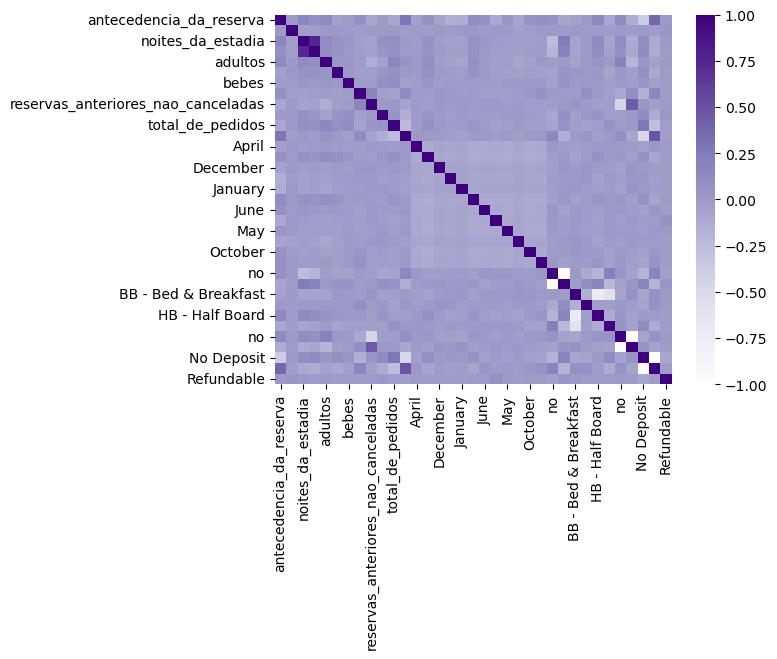

In [23]:
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap="Purples") 
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df.drop('cancelada', axis=1)
X

,antecedencia_da_reserva,dia_chegada,noites_da_estadia,noites_fim_de_semana,adultos,criancas,bebes,cancelamentos_anteriores,reservas_anteriores_nao_canceladas,alteracoes_da_reserva,...,yes,BB - Bed & Breakfast,FB - Full Board,HB - Half Board,SC - Self Catering,no,yes,No Deposit,Non Refund,Refundable
id,,,,,,,,,,,,,,,,,,,,,
1,26,25,7,2,3,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,0
2,31,1,2,0,2,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
5,4,17,3,0,2,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
8,6,1,1,0,1,0,0,0,0,0,...,1,1,0,0,0,1,0,1,0,0
12,65,12,4,2,2,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78545,108,11,2,0,2,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
78547,209,23,2,0,2,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0
78554,3,17,4,2,1,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0


In [26]:
y = df['cancelada']
y

id
1        0
2        1
5        1
8        0
12       1
        ..
78545    0
78547    0
78554    0
78555    0
78556    1
Name: cancelada, Length: 20000, dtype: int64

In [27]:
Xtreino, Xteste, ytreino, yteste = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [28]:
print(Xtreino.shape, Xteste.shape, ytreino.shape, yteste.shape)

(16000, 34) (4000, 34) (16000,) (4000,)


In [29]:
from sklearn.svm import SVC
from sklearn import svm

In [30]:
svc = svm.SVC(probability=True) 
svc

SVC(probability=True)

In [31]:
svc.fit(Xtreino,ytreino)

SVC(probability=True)

In [32]:
svc.score(Xtreino,ytreino)

0.667375

In [33]:
previsao=svc.predict(Xteste)

In [34]:
proba=svc.predict_proba(Xtreino)

In [35]:
proba=proba[:1]

In [36]:
d = pd.DataFrame( {'previsto': previsao, 'real': yteste})

In [37]:
pd.crosstab(d.real, d.previsto)

previsto,0,1
real,,
0,2331,176
1,1161,332


In [38]:
print("F1: ", metrics.f1_score(y_true=d.real, y_pred=d.previsto, pos_label=0))

F1:  0.777129521586931


In [39]:
diagnostico = pd.DataFrame( {'previsto': previsao, 'real': yteste})

In [40]:
dfnc = pd.read_csv('dataset_naoclassificado.csv', sep=';')

In [41]:
pd.crosstab(diagnostico.real, diagnostico.previsto)

previsto,0,1
real,,
0,2331,176
1,1161,332


In [42]:
print("F1 do SVC: ", metrics.f1_score(y_true=diagnostico.real,
                                 y_pred=diagnostico.previsto,
                                 pos_label=0))

F1 do SVC:  0.777129521586931


In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
valores = {'C': [0.1,1,10,100,1000], 'gamma': [1,0.1,0.01,0.001],'kernel': ['rbf', 'sigmoid']} 

In [45]:
procura_modelo = GridSearchCV(svc, param_grid=valores, cv=3, n_jobs=-1)

In [46]:
procura_modelo.fit(Xtreino, ytreino)

GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'sigmoid']})

In [47]:
procura_modelo.best_params_

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

In [48]:
modelo_optimo=procura_modelo.best_estimator_

In [49]:
modelo_optimo.score(Xteste, yteste)

0.76625

In [50]:
previsoes = modelo_optimo.predict(Xteste) 

In [51]:
proba = modelo_optimo.predict_proba(Xtreino)

In [52]:
probs = proba[:, 1]

In [53]:
diagnostico = pd.DataFrame( {'previsto': previsoes, 'real': yteste})

In [54]:
pd.crosstab(diagnostico.real, diagnostico.previsto)

previsto,0,1
real,,
0,2467,40
1,895,598


In [55]:
print("F1 melhorado: ", metrics.f1_score(y_true=diagnostico.real, y_pred=diagnostico.previsto, pos_label=0))

F1 melhorado:  0.8406883625830635


In [56]:
dfnc = pd.read_csv('dataset_naoclassificado.csv', sep=';')

In [57]:
dfnc = dfnc.set_index('id')

In [58]:
dfnc_mes_chegada = pd.get_dummies(dfnc['mes_chegada'])
dfnc_hotel_de_praia = pd.get_dummies(dfnc['hotel_de_praia'])
dfnc_regime = pd.get_dummies(dfnc['regime'])
dfnc_ja_cliente = pd.get_dummies(dfnc['ja_cliente'])
dfnc_tipo_deposito = pd.get_dummies(dfnc['tipo_deposito'])

In [59]:
dfnc = pd.concat([dfnc, dfnc_mes_chegada], axis=1).reindex(dfnc.index)
dfnc = pd.concat([dfnc, dfnc_hotel_de_praia], axis=1).reindex(dfnc.index)
dfnc = pd.concat([dfnc, dfnc_regime], axis=1).reindex(dfnc.index)
dfnc = pd.concat([dfnc, dfnc_ja_cliente], axis=1).reindex(dfnc.index)
dfnc = pd.concat([dfnc, dfnc_tipo_deposito], axis=1).reindex(dfnc.index)

In [60]:
dfnc.drop('mes_chegada', axis=1, inplace=True)
dfnc.drop('hotel_de_praia', axis=1, inplace=True)
dfnc.drop('regime', axis=1, inplace=True)
dfnc.drop('ja_cliente', axis=1, inplace=True)
dfnc.drop('tipo_deposito', axis=1, inplace=True)

In [61]:
dfnc.dropna(inplace=True)

In [62]:
yprev = modelo_optimo.predict(dfnc)
yprev

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [63]:
yteste.sort_index(axis=0)

id
1        0
5        1
14       0
19       1
89       0
        ..
78437    0
78454    0
78469    0
78494    1
78510    0
Name: cancelada, Length: 4000, dtype: int64

In [64]:
classificacao = pd.DataFrame({'id':dfnc.index, 'cancelada':yprev.astype('int')})

In [65]:
classificacao.to_csv('classificacao_estimada.csv', index=False, sep=';')

In [66]:
df = pd.read_csv('classificacao_estimada.csv', sep=";")
df = df.set_index("id")
df

,cancelada
id,
78557,0
78559,0
78565,0
78571,0
78583,0
...,...
118199,0
118203,0
118205,0
